In [5]:
import numpy as np
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import os
import random
from scipy.stats import spearmanr, pearsonr

In [6]:
amino_acid = np.load('./model/categorical_variables.npy', allow_pickle=True)
num_aa = len(amino_acid)
ohe = np.load('./data/x_test.npy', allow_pickle=True)
seq_len = np.load('./data/len_test.npy', allow_pickle=True)
seq_len = seq_len.astype(int)
imp = np.load('./model/importance_test.npy', allow_pickle=True)
prop = np.load(file='./data/y_test.npy', allow_pickle=True)

In [7]:
print("ohe shape:", ohe.shape)
print("seq_len shape:", seq_len.shape)

ohe shape: (64, 50, 21)
seq_len shape: (64,)


In [8]:
# Convert one-hot encoded sequences back to amino acid sequences
sequence_list = []
for i in range(ohe.shape[0])                                                            :
    seq = ''
    for j in range(seq_len[i]):
        aa_index = np.argmax(ohe[i, j])
        seq += amino_acid[aa_index]
    sequence_list.append(seq)

print (sequence_list[:5])  # Print first 5 sequences to verify

['DAAYKLQPWQNCHCFTNPWESYIYMVSARCDAYEGMHWNDRKIYIDGYFK', 'CSVFCMCCCILKRRSDDHWMAMDIKTSSQLMDAYNIGHGIQPCICWTLPE', 'FPWGGWCSVTVKWNQRWRGIDCADGLRVAHRQQKTMVGRRLFNEYIACPV', 'LEMPNYRVHQEFQGHWLYKIPVMEHAKPSKDDWNREGHWRFMNWTNMPSC', 'KIKWDVQYWCQIRHIVLGRGANNYLKSFEFVFWKESMYNWVGFGMIIFKH']


In [9]:
dict_score = {}
for i in range(num_aa):
    dict_score[i] = []
    
score = np.zeros((len(amino_acid),))
count = np.zeros((len(amino_acid),))

N = ohe.shape[0]
for i in range(N):
    if prop[i] != 0:
        l = int(seq_len[i])
        x = np.argmax(ohe[i,0:l,:],axis=-1)
        sample_imp = imp[i,0:l]#/max(imp[i,0:l])
        for aa in range(num_aa):
            idx = (x==aa)
            score[aa] += np.sum(sample_imp[idx])
            count[aa] += np.sum(idx*1)
            mean_imp = (np.sum(sample_imp[idx])/(np.sum(idx*1)+1E-18))
            if mean_imp != 0:
                dict_score[aa].append(mean_imp)

# score = np.mean(d)
score = score/count
score = score/max(score)

/var/folders/01/rff9bm5d6wd81z2fbgg0brf40000gn/T/ipykernel_78868/1438064929.py:23: RuntimeWarning: invalid value encountered in divide
  score = score/count


In [10]:
GRAVY_VALUES = {str(amino_acid[i]): float(score[i]) for i in range(num_aa)}

print(GRAVY_VALUES)

{'A': 0.5564718965504678, 'V': 0.8560680733826156, 'F': 0.6319596130734586, 'I': 1.0, 'L': 0.9464890754885759, 'D': 0.7159110324173091, 'E': 0.720499826729504, 'K': 0.7727742911102835, 'S': 0.21467988509694874, 'T': 0.29988442931970455, 'Y': 0.2877641483969602, 'C': 0.5893178452996854, 'N': 0.6981751999702079, 'Q': 0.7181466628169211, 'P': 0.4449876001359302, 'M': 0.5095292821150865, 'R': 0.8108927873662434, 'H': 0.6385256214404139, 'W': 0.22077071455888525, 'G': 0.2706183833957799, 'X': nan}


In [11]:
def calculate_gravy(sequence):
    return sum(GRAVY_VALUES.get(aa, 0) for aa in sequence) / len(sequence)

# Calculate GRAVY scores for all sequences
ground_truth_gravy = [calculate_gravy(seq) for seq in sequence_list]

print(ground_truth_gravy[:5])  # Print first 5 GRAVY scores to verify

[0.5736270332320305, 0.6077156915404582, 0.6073008465427211, 0.5881980426907337, 0.6270108661548837]


In [12]:
def mask_sequences(sequences, importance_scores, per=10, top_per=100, high_to_low=True):
    """
    Mask sequences by step size = sequence_length * (per / 100).
    
    Parameters:
    - sequences: List of amino acid sequences (strings)
    - importance_scores: Dictionary mapping amino acids to importance scores
    - per: Percentage of sequence length to mask per step (default 10%)
    - top_per: Percentage of top positions to consider (default 100%)
    - high_to_low: Sort by importance high to low (default True)
    
    Returns:
    - List of lists of masked sequences, one list per sequence
    """
    masked_sequences_list = [[] for _ in sequences]

    for seq_index, seq in enumerate(sequences):
        seq_len = len(seq)
        
        # Calculate step size as per% of THIS sequence's length
        step_size = max(1, ceil(seq_len * per / 100))
        
        visited_indices = set()

        # Compute importance score per position
        scores = [importance_scores.get(aa, 0.0) for aa in seq]

        # Sort indices by importance score
        sorted_indices = list(range(seq_len))
        sorted_indices.sort(key=lambda i: scores[i], reverse=high_to_low)

        # Limit to top_per% of positions
        top_k = ceil(seq_len * top_per / 100)
        sorted_indices = sorted_indices[:top_k]

        # Break into chunks of step_size (dynamic per sequence)
        chunks = [sorted_indices[i:i + step_size] for i in range(0, len(sorted_indices), step_size)]

        for chunk in chunks:
            new_seq = list(seq)  # Start from original each time
            for i in chunk:
                if i not in visited_indices:
                    new_seq[i] = 'X'
                    visited_indices.add(i)
            masked_sequences_list[seq_index].append(''.join(new_seq))

    return masked_sequences_list


def analyze_masked_sequences(masked_sequences_list, importance_scores, sequences, per=10):
    """
    Constructs a DataFrame with masked sequences and importance score per masking step.

    Parameters:
    - masked_sequences_list: List of lists of masked sequences (output from mask_sequences).
    - importance_scores: Dictionary mapping amino acids to importance scores.
    - sequences: Original sequences (to calculate per-sequence step counts)
    - per: Percent step used in masking (default is 10%).

    Returns:
    - DataFrame with columns for each masking step's sequence and importance score.
    """
    # Get max number of masking steps across all sequences
    max_steps = max(len(seq_variants) for seq_variants in masked_sequences_list)
    
    print(f"Per masking step: {per}%")
    print(f"Max masking steps across all sequences: {max_steps}")
    
    columns = []
    for i in range(max_steps):
        columns.append(f"{i+1}_{per}%_masked_seq")
        columns.append(f"{i+1}_{per}%_importance")

    data = []
    for seq_index, seq_variants in enumerate(masked_sequences_list):
        row = []
        for masked_seq in seq_variants:
            # Extract unmasked amino acids
            unmasked_aas = [aa for aa in masked_seq if aa != 'X']
            # Compute importance score
            if unmasked_aas:
                importance_score = sum(importance_scores.get(aa, 0.0) for aa in unmasked_aas) / len(unmasked_aas)
            else:
                importance_score = None
            row.extend([masked_seq, importance_score])
        
        # Pad row if fewer steps than max
        while len(row) < len(columns):
            row.extend([None, None])
        data.append(row)

    return pd.DataFrame(data, columns=columns)

In [13]:
masked_sequences_list = mask_sequences(sequence_list, GRAVY_VALUES, high_to_low=True)

print(masked_sequences_list)

[['...']]


In [14]:
df = analyze_masked_sequences(masked_sequences_list , GRAVY_VALUES, sequences= sequence_list, per=10)

Per masking step: 10%
Max masking steps across all sequences: 10


In [15]:
df.head()

,1_10%_masked_seq,1_10%_importance,2_10%_masked_seq,2_10%_importance,3_10%_masked_seq,3_10%_importance,4_10%_masked_seq,4_10%_importance,5_10%_masked_seq,5_10%_importance,6_10%_masked_seq,6_10%_importance,7_10%_masked_seq,7_10%_importance,8_10%_masked_seq,8_10%_importance,9_10%_masked_seq,9_10%_importance,10_10%_masked_seq,10_10%_importance
0,DAAYKXQPWQNCHCFTNPWESYXYMXSARCDAYEGMHWNDRKXYXD...,0.530640,DAAYXLQPWQNCHCFTNPWESYIYMVSAXCDAYEGMHWNDXXIYID...,0.549805,XAAYKLXPWXNCHCFTNPWXSYIYMVSARCDAYXGMHWNDRKIYID...,0.557514,DAAYKLQPWQXCHCFTXPWESYIYMVSARCXAYEGMHWNXRKIYIX...,0.558606,DAAYKLQPWQNCXCXTNPWESYIYMVSARCDAYEGMXWXDRKIYID...,0.565382,DXXYKLQPWQNXHXFTNPWESYIYMVSARXDAYEGMHWNDRKIYID...,0.573343,DAAYKLQXWQNCHCFTNPWESYIYXVSXRCDXYEGXHWNDRKIYID...,0.580097,DAAXKLQPWQNCHCFXNXWESXIXMVSARCDAYEGMHWNDRKIYID...,0.601626,DAAYKLQPWQNCHCFTNPWESYIYMVSARCDAXEXMHWNDRKIXID...,0.606152,DAAYKLQPXQNCHCFTNPXEXYIYMVXARCDAYEGMHXNDRKIYID...,0.613104
1,CSVFCMCCCXLKRRSDDHWMAMDXKTSSQLMDAYNXGHGXQPCXCW...,0.564129,CSXFCMCCCIXKXRSDDHWMAMDIKTSSQXMDAYNIGHGIQPCICW...,0.575097,CSVFCMCCCILXRXSDDHWMAMDIXTSSXLMDAYNIGHGIQPCICW...,0.590904,CSVFCMCCCILKRRSXXHWMAMXIKTSSQLMXAYNIGHGIXPCICW...,0.595644,XSVXCMCCCILKRRSDDXWMAMDIKTSSQLMDAYXIGXGIQPCICW...,0.604206,CSVFXMXXXILKRRSDDHWMAMDIKTSSQLMDAYNIGHGIQPXICW...,0.609760,CSVFCXCCCILKRRSDDHWXXMDIKTSSQLMDXYNIGHGIQPCIXW...,0.614766,CSVFCMCCCILKRRSDDHWMAXDIKXSSQLXDAYNIGHGIQXCICW...,0.626153,CSVFCMCCCILKRRSDDHXMAMDIKTSSQLMDAXNIXHXIQPCICW...,0.645247,CXVFCMCCCILKRRXDDHWMAMDIKTXXQLMDAYNIGHGIQPCICX...,0.651251
2,FPWGGWCSXTVKWNQRWRGXDCADGXRVAHRQQKTMVGRRXFNEYX...,0.569244,FPWGGWCSVTXKWNQXWRGIDCADGLRXAHRQQKTMXGRRLFNEYI...,0.580664,FPWGGWCSVTVKWNQRWXGIDCADGLXVAHXQQKTMVGXXLFNEYI...,0.584680,FPWGGWCSVTVXWNXRWRGIDCADGLRVAHRXQXTMVGRRLFNXYI...,0.592504,FPWGGWCSVTVKWXQRWRGIXCAXGLRVAHRQXKTMVGRRLFXEYI...,0.595972,XPWGGWXSVTVKWNQRWRGIDXADGLRVAXRQQKTMVGRRLXNEYI...,0.606310,FPWGGWCSVTVKWNQRWRGIDCXDGLRVXHRQQKTXVGRRLFNEYI...,0.613262,FXWGGWCSVXVKWNQRWRGIDCADGLRVAHRQQKXMVGRRLFNEXI...,0.635279,FPWXXWCSVTVKWNQRWRXIDCADXLRVAHRQQKTMVXRRLFNEYI...,0.644710,FPXGGXCXVTVKXNQRXRGIDCADGLRVAHRQQKTMVGRRLFNEYI...,0.650384
3,XEMPNYRXHQEFQGHWXYKXPXMEHAKPSKDDWNREGHWRFMNWTN...,0.551218,LEMPNYXVHQEFQGHWLYXIPVMEHAXPSKDDWNXEGHWXFMNWTN...,0.565148,LXMPNYRVHQXFQGHWLYKIPVMXHAKPSXDDWNRXGHWRFMNWTN...,0.572336,LEMPXYRVHXEFXGHWLYKIPVMEHAKPSKXXWNREGHWRFMNWTN...,0.574302,LEMPNYRVXQEFQGXWLYKIPVMEHAKPSKDDWXREGHWRFMXWTX...,0.578629,LEMPNYRVHQEXQGHWLYKIPVMEXAKPSKDDWNREGXWRXMNWTN...,0.583991,LEXPNYRVHQEFQGHWLYKIPVXEHXKPSKDDWNREGHWRFXNWTN...,0.595896,LEMXNYRVHQEFQGHWLYKIXVMEHAKXSKDDWNREGHWRFMNWXN...,0.607335,LEMPNXRVHQEFQXHXLXKIPVMEHAKPSKDDWNREXHWRFMNWTN...,0.623830,LEMPNYRVHQEFQGHWLYKIPVMEHAKPXKDDXNREGHXRFMNXTN...,0.629294
4,KXKWDVQYWCQXRHXVLGRGANNYLKSFEFVFWKESMYNWVGFGMX...,0.585568,KIKWDXQYWCQIRHIXXGRGANNYXKSFEFXFWKESMYNWVGFGMI...,0.597541,XIXWDVQYWCQIXHIVLGXGANNYLKSFEFVFWKESMYNWXGFGMI...,0.607270,KIKWDVQYWCQIRHIVLGRGANNYLXSFXFVFWXXSMYNWVGFGMI...,0.613138,KIKWXVXYWCXIRHIVLGRGAXXYLKSFEFVFWKESMYNWVGFGMI...,0.617822,KIKWDVQYWCQIRXIVLGRGANNYLKSXEXVFWKESMYXWVGFGMI...,0.624698,KIKWDVQYWXQIRHIVLGRGXNNYLKSFEFVXWKESMYNWVGXGMI...,0.629086,KIKWDVQXWCQIRHIVLGRGANNXLKSFEFVFWKESXXNWVGFGXI...,0.654849,KIKXDVQYWCQIRHIVLXRXANNYLKSFEFVFWKESMYNWVXFXMI...,0.667718,KIKWDVQYXCQIRHIVLGRGANNYLKXFEFVFXKEXMYNXVGFGMI...,0.672419


In [30]:
def plot_deviation_per_sample(df, ground_truth, sample_index, importance_scores, sequence_list, step_percent=10):
    """
    Plots importance deviation vs. mean unmasked importance scores for a single sample.

    Parameters:
    - df: DataFrame from analyze_masked_sequences with masked sequences and scores per step.
    - ground_truth: List of ground truth instability scores per sample.
    - sample_index: Index of the sample to plot.
    - importance_scores: Dictionary mapping amino acid positions to importance scores.
    - sequence_list: List of original sequences.
    - step_percent: Percent step used in masking (default is 10%).
    """
    row = df.iloc[sample_index]
    original_sequence = sequence_list[sample_index]
    
    x_vals = []
    y_vals = []

    num_steps = len(row) // 2  # Each step has a masked_seq and a property column

    for step in range(1, num_steps + 1):
        masked_seq_col = f"{step}_{step_percent}%_masked_seq"
        prop_col = f"{step}_{step_percent}%_importance"

        if masked_seq_col in row and prop_col in row and not pd.isna(row[prop_col]):
            masked_seq = row[masked_seq_col]
            masked_prop = row[prop_col]
            
            # Calculate mean importance score of unmasked positions
            unmasked_importance_scores = []
            for i, aa in enumerate(masked_seq):
                if aa != 'X':  # Unmasked position
                    # Get importance score for this position
                    key = original_sequence[i]  # Use original AA as key
                    if key in importance_scores:
                        unmasked_importance_scores.append(importance_scores[key])
            
            if unmasked_importance_scores:
                mean_unmasked_importance = sum(unmasked_importance_scores) / len(unmasked_importance_scores)
                deviation = masked_prop - ground_truth[sample_index]
                
                x_vals.append(mean_unmasked_importance)
                y_vals.append(deviation)

    if x_vals and y_vals:
        spearman_corr, p_value = spearmanr(x_vals, y_vals)
        plt.figure(figsize=(8, 5))
        plt.scatter(x_vals, y_vals, color='blue')
        plt.plot(x_vals, y_vals, linestyle='--', alpha=0.5)
        plt.show()
        print("Spearman correlation:", spearman_corr)

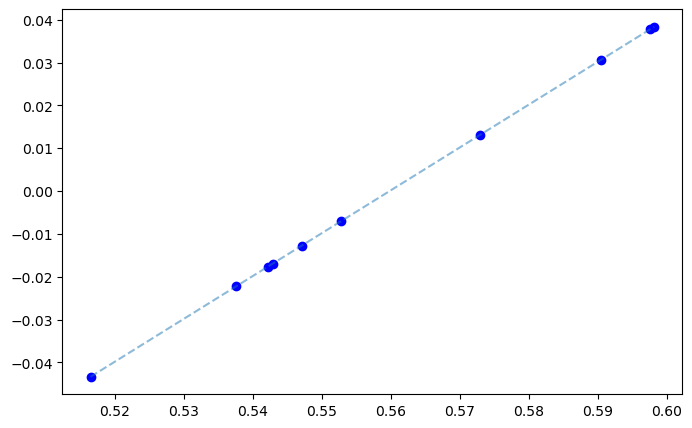

Spearman correlation: 0.9999999999999999


In [33]:
plot_deviation_per_sample(df, ground_truth=ground_truth_gravy,sample_index=5, importance_scores=GRAVY_VALUES, sequence_list=sequence_list, step_percent=10)